In [1]:
from scipy.stats import entropy
import os
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from resources import party_merge

members = pd.read_csv('/home/rb/Documents/Data/metadata/members.csv',sep='\t')

In [2]:
from helper import *

In [3]:
control_topics = [78,100,253,88,317,194]

In [4]:
df = pd.read_csv('/home/rb/Downloads/lda/lda/data-1945-2022-chunked/averaged_topics.csv')
kd = pd.read_csv('/home/rb/Downloads/lda/lda/data-1945-2022-chunked/topic-keys.txt',sep='\t',header=None)
ks = dict(zip(kd[0],kd[2]))
dfd = df.drop(columns=['member_or_speaker','party-ref'])
dfd.index = pd.to_datetime(df.date).dt.to_period('D')
dfd = dfd.drop(columns=['date']).groupby(dfd.index).mean()
df = df.drop(columns=['member_or_speaker','party-ref'])

In [5]:
dfs = df[pd.to_datetime(df.date).dt.year > 2000]

In [8]:
#.rename(columns=dict(zip(kd[0].astype(str),kd[2].str[:50])))

In [9]:
corr_macro = dfs.set_index("date").corr()
cma_flat = corr_macro.stack().reset_index()
# cma_flat = cma_flat.query(f"level_0 == '{ks[78][:50]}'").nlargest(15,0)

In [10]:
corr_micro = dfs[pd.to_datetime(dfs.date).dt.year == 2010].set_index("date").corr()
cmi_flat = corr_micro.stack().reset_index()
# cma_flat = cma_flat.query(f"level_0 == '{ks[78][:50]}'").nlargest(15,0).set_index("date").rename(columns=dict(zip(kd[0].astype(str),kd[2].str[:50]))).corr()

In [13]:
cma_flat['pair'] = cma_flat[['level_0','level_1']].agg('-'.join,axis=1)
cmi_flat['pair'] = cmi_flat[['level_0','level_1']].agg('-'.join,axis=1)

In [14]:
cma_flat_pair_dict = dict(zip(cma_flat.pair, cma_flat[0]))

In [24]:
cmi_flat['norm'] = cmi_flat.apply(lambda x: x[0] / cma_flat_pair_dict[x['pair']], axis=1)

In [26]:
cmi_flat['tgk'] = cmi_flat.level_1.astype(int).map(ks)

In [30]:
cmi_flat[(cmi_flat.level_0 == "78") & (cmi_flat[0] > 0.1)].nlargest(15,"norm")

,level_0,level_1,0,pair,norm,tgk
39495,78,495,0.453512,78-495,17.840355,bedrijfsorganisatie bedrijfsleven publiekrecht...
39232,78,232,0.118668,78-232,9.078767,parlement regering parlementair controle kamer...
39317,78,317,0.119904,78-317,2.620000,toezicht toezichthouder controle onafhankelijk...
39078,78,78,1.000000,78-78,1.000000,controle financieel verantwoording jaarverslag...
39494,78,494,0.116698,78-494,-56.182100,regering plaatsing onderhandeling nederlands k...
39316,78,316,0.109554,78-316,-141.121396,geacht heer afgevaardigen afgevaardigde mijnhe...


In [ ]:
results = rolling_partial_corr_fast(
    df=dfs,
    date_col="date",
    topic_cols=[str(x) for x in range(500)],
    topic_pairs=[("78",str(i)) for i in range(100)],
    window=2,                  # 5-year rolling window
    min_obs=500,              # skip windows with fewer than 1000 speeches
    alpha=0.05,                # Lasso regularization
    max_speeches_per_year=1000  # optional: sample at most 500 speeches per year
)

Years:   0%|          | 0/22 [00:00<?, ?yr/s]

<Axes: xlabel='year'>

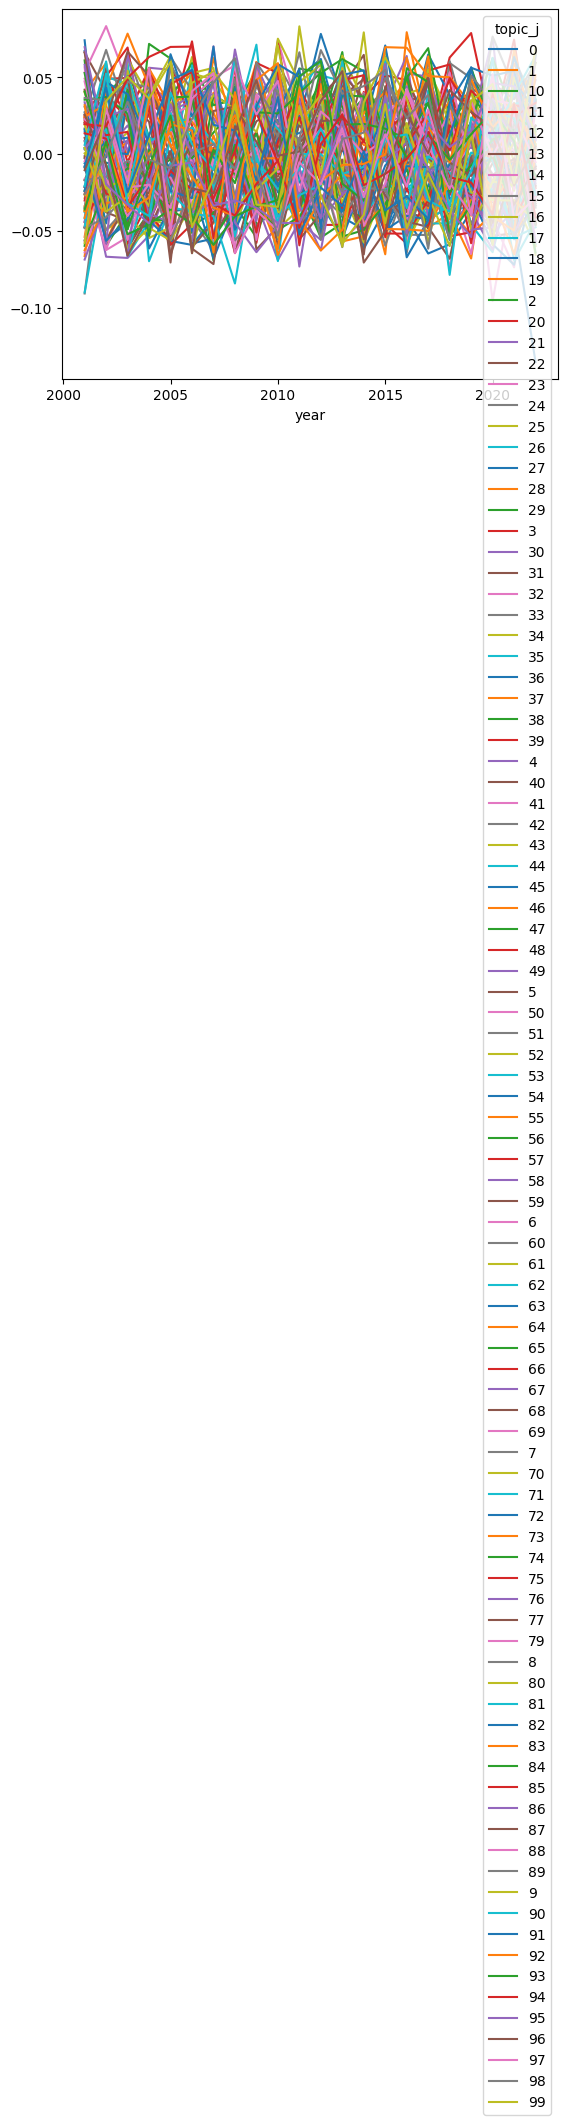

In [17]:
results[results.topic_j!="78"].groupby(['year','topic_j']).partial_corr.mean().unstack().plot()

In [ ]:
df.set_index('date').corr()

In [24]:
results['topic_j'] = results.topic_j.astype(int).map(ks).str[:50]

In [26]:
results = results[~results.topic_j.str.startswith('huurder ')]

In [28]:
results.groupby('topic_j').partial_corr.mean().nlargest(15)

topic_j
stad groot klein platteland dorp gemeente gebied k    0.020569
rechter procedure wetsvoorstel wet geval bewijslas    0.015355
motie stuk kamer heer oordeel mevrouw regering ont    0.015062
europees nederlands land brexit premier lidstaat v    0.014410
motie kamer regering orde dag beraadslaging lid vo    0.013956
wet bevoegdheid artikel bepaling wettelijk algemee    0.010527
experiment vernieuwing sociaal gemeente beleid bre    0.010105
motie kamer heer fractie debat meerderheid duideli    0.009737
handel land nederlands europees verdrag markt bedr    0.009548
staatssecretaris punt termijn vraag antwoord voorz    0.009221
natuur boer gebied provincie stikstof landbouw doe    0.008208
verkeer waterstaat minister weg aanleg verbinding     0.008007
heer minister vergadering zaak mijnheer zitting og    0.007567
punt discussie voorzitter termijn heer vraag colle    0.007285
regel regelgeving administratief wetgeving deregul    0.006730
Name: partial_corr, dtype: float64

In [27]:
results.nlargest(15,'partial_corr')

,year,topic_i,topic_j,partial_corr,n_obs
1665,2017,96,kabinet mld jaar lastenverlichting financiën s...,0.096761,500
1761,2018,96,vergunning voorwaarde aanvraag geval eis aanvr...,0.093433,500
610,2007,96,staatssecretaris geval regeling fractie voorzi...,0.093423,500
42,2001,96,regering financieel uitgave algemeen beschouwi...,0.088788,500
2088,2021,96,integriteit code transparantie gedragscode reg...,0.088463,500
1486,2015,96,economisch consument mededinging verticaal koo...,0.088214,500
866,2009,96,land mensenrechten regering nederlands mensenr...,0.086305,500
155,2002,96,heer natuurlijk heel echt vraag ding goed mome...,0.086081,500
199,2002,96,punt discussie voorzitter termijn heer vraag c...,0.085526,500
633,2007,96,defensie krijgsmacht militair personeel taak d...,0.085417,500


In [50]:
from scipy.special import softmax

In [45]:
r = (
    df
    .groupby(pd.to_datetime(df.date).dt.to_period('Q'))
    .apply(
        lambda x: (
            x.drop(columns=['date'])
             .corr()
             .unstack()
             .reset_index(name="correlation")  # correlation values column
             .rename(columns={'level_0': 'var1', 'level_1': 'var2'})
             .assign(year=x.name)  # add year column
        )
    )
    .reset_index(drop=True)  # flatten final DataFrame and remove old multi-index
)

In [46]:
r['t1'] = r.var1.astype(int).map(ks)
r['t2'] = r.var2.astype(int).map(ks)

In [47]:
rp = r[(r.var1=="78") & (r.var2!="78")].groupby(["year","t2"]).correlation.mean().unstack()

In [63]:
def row_softmax(x):
    e_x = np.exp(x - np.max(x))  # subtract max for numerical stability
    return e_x / e_x.sum(axis=1, keepdims=True)

df_softmax = pd.DataFrame(row_softmax(rp.to_numpy()), columns=rp.columns)

In [55]:
from pymannkendall import original_test as pm

In [73]:
rps=rp.ewm(span=12).mean().apply(lambda x: pm(x).slope)

<Axes: xlabel='year'>

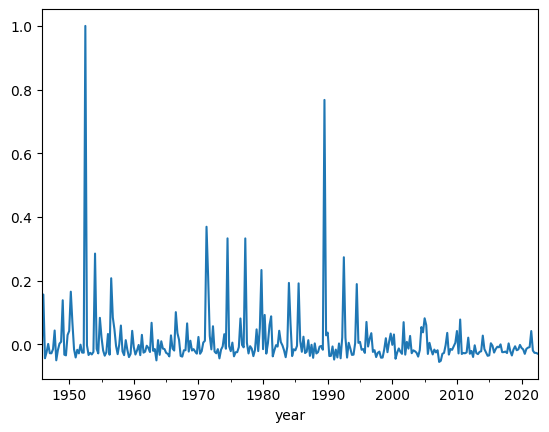

In [76]:
rp['markt concurrentie marktwerking consument prijs goed tarief liberalisering overheid bedrijf vrij aanbieder spraak belang klant sector partij laag aanbod kost '].plot()

<Axes: xlabel='year'>

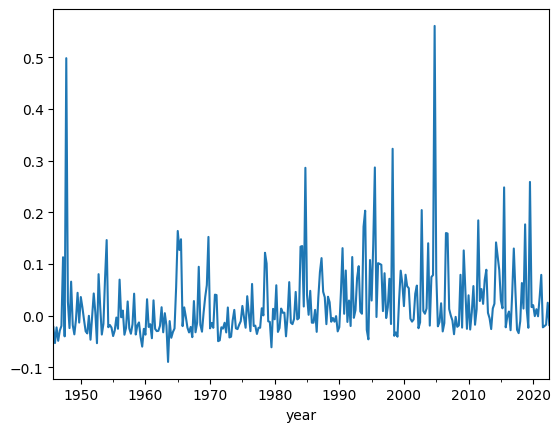

In [78]:
rp['informatie goed vraag signal heel kamer belangrijk melding echt beeld moment aantal mevrouw ministerie manier natuurlijk website aanleiding onderzoek mens '].plot()

In [31]:
df = pd.read_excel('/home/rb/Documents/Code/Rekenkamer/_DATA/rekenkamer.xlsx')

In [36]:
df.loc[7]['doc_url']

'https://www.rekenkamer.nl/binaries/rekenkamer/documenten/kamerstukken/2012/05/16/antwoorden-op-kamervragen-rapport-detentie-behandeling-en-nazorg-criminele-jeugdigen-terugblik/Brief+aan+TK.pdf'

In [42]:
df[df._id.str.contains('vragen')]._id.tolist()

['rekenkamer__kamerstuk:2012:02:13:beantwoording-kamervragen-over-het-rapport-kosten-jeugdbescherming-en-jeugdreclassering',
 'rekenkamer__kamerstuk:2012:03:13:beantwoording-kamervragen-over-het-rapport-vastgoed-van-het-rijk-volume-en-waarde',
 'rekenkamer__kamerstuk:2012:05:03:beantwoording-kamervragen-over-het-rapport-prestaties-in-de-strafrechtketen',
 'rekenkamer__kamerstuk:2012:05:16:antwoorden-op-kamervragen-rapport-detentie-behandeling-en-nazorg-criminele-jeugdigen-terugblik',
 'rekenkamer__kamerstuk:2012:05:16:antwoorden-op-kamervragen-rapport-monitoring-vervanging-f-16',
 'rekenkamer__kamerstuk:2012:05:16:beantwoording-kamervragen-bij-het-rapport-bij-het-jaarverslag-2011-van-de-nationale-schuld',
 'rekenkamer__kamerstuk:2012:06:11:beantwoording-kamervragen-over-het-rapport-bij-het-jaarverslag-2011-van-het-ministerie-van-defensie',
 'rekenkamer__kamerstuk:2012:06:11:beantwoording-kamervragen-rapport-bij-het-jaarverslag-2011-van-het-ministerie-van-algemene-zaken',
 'rekenkamer__

---
## Evaluatiediscours in het Nederlandse parlement (1945–2022)

### Deel 1: Prominentie van evaluatietopics over tijd

Gebruik resultaten van `eval_prominence.py` — jaargemiddelden, periodegemiddelden en structuurbreuken.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from pathlib import Path

RESULTS = Path("../results")
FIGS    = RESULTS / "figs"

EVAL_TOPICS = {
    78:  "T78 · Fin. verantwoording",
    88:  "T88 · Integriteit",
    100: "T100 · Inspectie",
    194: "T194 · Beleidsevaluatie",
    253: "T253 · Fraude",
    317: "T317 · Toezichthouders",
}
EVAL_COLS = [str(t) for t in EVAL_TOPICS]

PERIODS = {
    "1945–1969": (1945, 1969),
    "1970–1979": (1970, 1979),
    "1980–1989": (1980, 1989),
    "1990–1999": (1990, 1999),
    "2000–2009": (2000, 2009),
    "2010–2022": (2010, 2022),
}


In [2]:
# Load precomputed yearly means
yearly = pd.read_csv(RESULTS / "eval_topics_yearly.csv", index_col=0)
composite = pd.read_csv(RESULTS / "eval_composite_yearly.csv", index_col=0).squeeze()
period_df = pd.read_csv(RESULTS / "eval_topics_period_means.csv", index_col=0)

print("Yearly data shape:", yearly.shape)
print("\nPeriod means (× 1000):")
(period_df * 1000).round(2)


Yearly data shape: (78, 6)

Period means (× 1000):


,78,88,100,194,253,317
1945–1969,0.71,0.18,0.33,0.29,0.30,0.51
1970–1979,0.99,0.26,0.32,0.64,0.67,0.45
1980–1989,2.20,0.27,0.48,1.61,1.35,0.59
1990–1999,1.70,0.71,0.81,2.85,1.30,1.60
2000–2009,1.49,2.03,2.17,2.69,1.88,2.51
2010–2022,0.99,1.58,2.85,2.52,2.04,1.98


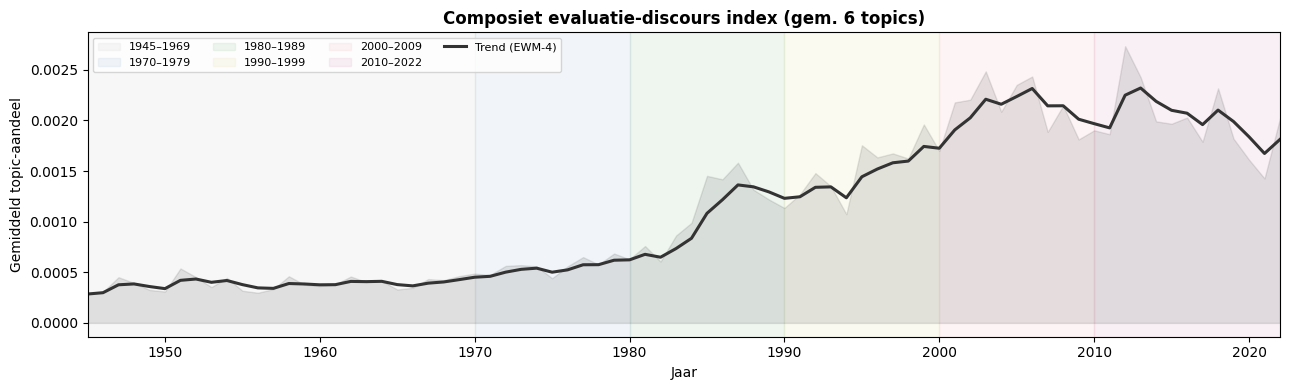

In [3]:
# ── Figure: Composiet index met periodemarkering ──────────────────────────────
PERIOD_COLORS = ["#999999","#4477AA","#228833","#CCBB44","#EE6677","#AA3377"]

fig, ax = plt.subplots(figsize=(13,4))
smoothed = composite.ewm(span=4).mean()

for (label,(y0,y1)), color in zip(PERIODS.items(), PERIOD_COLORS):
    ax.axvspan(y0, min(y1+1,2023), alpha=0.07, color=color, label=label)

ax.fill_between(composite.index, composite.values, alpha=0.12, color="#333333")
ax.plot(smoothed.index, smoothed.values, lw=2.2, color="#333333", label="Trend (EWM-4)")
ax.set_title("Composiet evaluatie-discours index (gem. 6 topics)", fontweight="bold")
ax.set_xlabel("Jaar"); ax.set_ylabel("Gemiddeld topic-aandeel")
ax.legend(fontsize=8, ncol=4, loc="upper left")
ax.set_xlim(1945,2022)
fig.tight_layout()
plt.savefig(FIGS/"eval_composite_index.png", dpi=150, bbox_inches="tight")
plt.show()


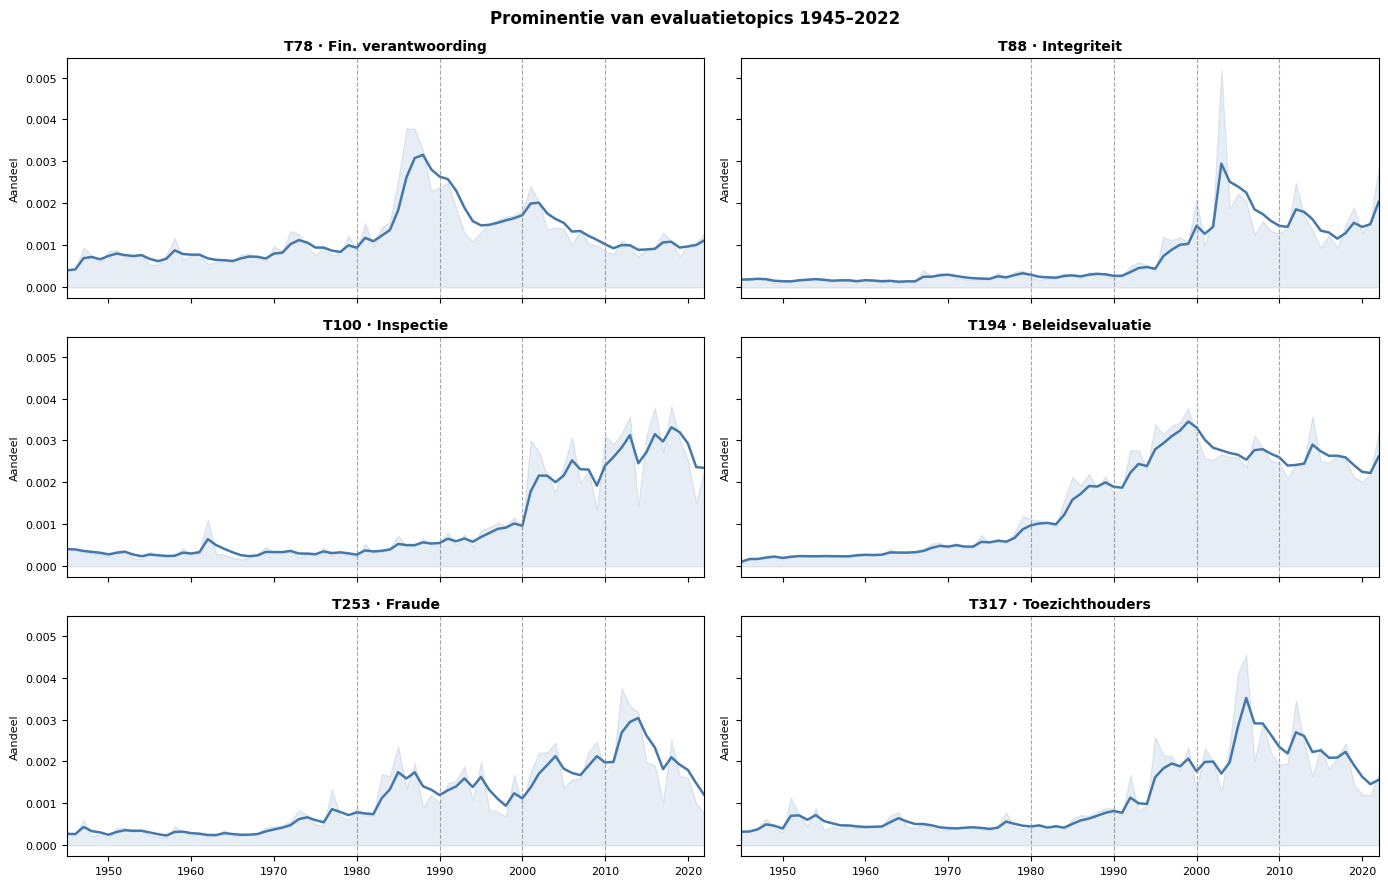

In [5]:
# ── Figure: Individuele topics met trendlijn ──────────────────────────────────
fig, axes = plt.subplots(3,2, figsize=(14,9), sharex=True, sharey=True)
axes = axes.flatten()
smoothed_all = yearly[EVAL_COLS].ewm(span=4).mean()
breaks = [1980, 1990, 2000, 2010]

for ax, (tid, label) in zip(axes, EVAL_TOPICS.items()):
    col = str(tid)
    ax.fill_between(yearly.index, yearly[col], alpha=0.13, color="#4477AA")
    ax.plot(smoothed_all.index, smoothed_all[col], lw=1.8, color="#4477AA")
    for bk in breaks:
        ax.axvline(bk, color="grey", ls="--", lw=0.8, alpha=0.7)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylabel("Aandeel", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.set_xlim(1945, 2022)

fig.suptitle("Prominentie van evaluatietopics 1945–2022", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig(FIGS/"eval_topics_individual.png", dpi=150, bbox_inches="tight")
plt.show()


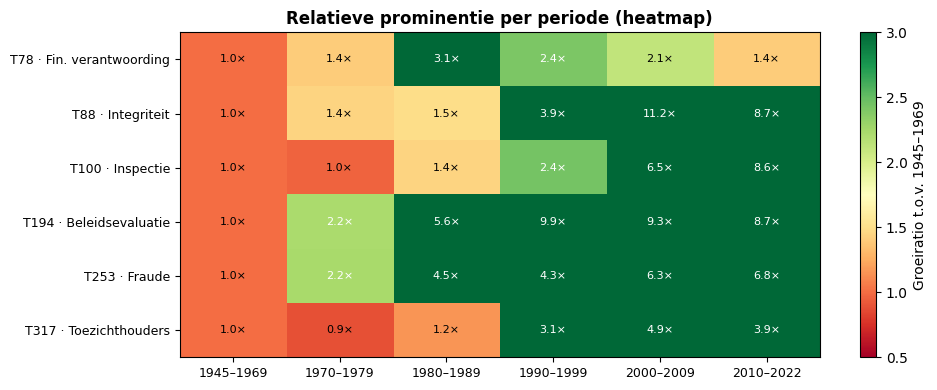


Samenvattend:
  1945–1969: 1.0×
  1970–1979: 1.4×
  1980–1989: 2.8×
  1990–1999: 3.9×
  2000–2009: 5.5×
  2010–2022: 5.2×


In [6]:
# ── Figure: Relatieve groei t.o.v. 1945-1969 baseline ────────────────────────
baseline = period_df.loc["1945–1969"]
ratios = period_df.div(baseline)

fig, ax = plt.subplots(figsize=(10,4))
cax = ax.imshow(ratios.T.values, aspect="auto", cmap="RdYlGn", vmin=0.5, vmax=3.0)
fig.colorbar(cax, ax=ax, label="Groeiratio t.o.v. 1945–1969")
ax.set_xticks(range(len(PERIODS))); ax.set_xticklabels(list(PERIODS.keys()), fontsize=9)
ax.set_yticks(range(len(EVAL_TOPICS))); ax.set_yticklabels(list(EVAL_TOPICS.values()), fontsize=9)
ax.set_title("Relatieve prominentie per periode (heatmap)", fontweight="bold")
for i, row in enumerate(ratios.T.values):
    for j, v in enumerate(row):
        ax.text(j, i, f"{v:.1f}×", ha="center", va="center", fontsize=8,
                color="black" if 0.8 < v < 2.2 else "white")
fig.tight_layout()
plt.savefig(FIGS/"eval_period_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSamenvattend:")
composite_ratios = period_df.mean(axis=1).div(period_df.mean(axis=1).iloc[0])
for p, r in composite_ratios.items():
    print(f"  {p}: {r:.1f}×")


---
### Deel 2: Thematische associaties per periode

Partiële correlaties (CLR-getransformeerde daggemiddelden) van T78 (financiële verantwoording)
met alle 500 andere topics per 10-jarige periode.

Stap 1: welke topics zijn stabiel geassocieerd (in alle periodes)?
Stap 2: welke topics zijn opkomend of afnemend?


In [7]:
# Load per-period top associations for T78
period_labels = ["1970–1979","1980–1989","1990–1999","2000–2009","2010–2022"]
period_dfs = {}
for p in period_labels:
    fname = RESULTS / f"eval_T78_top_assoc_{p.replace('–','-')}.csv"
    period_dfs[p] = pd.read_csv(fname)
    print(f"{p}: {len(period_dfs[p])} rows, top topic = T{period_dfs[p].iloc[0].topic_id:.0f} "
          f"(r={period_dfs[p].iloc[0].r_partial:.3f}) — {period_dfs[p].iloc[0].keywords[:50]}")


1970–1979: 30 rows, top topic = T220 (r=0.138) — onderzoek wetenschappelijk wetenschap minister ins
1980–1989: 30 rows, top topic = T319 (r=0.169) — departement ambtenaar minister ambtelijk dienst mi
1990–1999: 30 rows, top topic = T129 (r=0.183) — begroting post uitgave jaar bedrag kamer
2000–2009: 30 rows, top topic = T425 (r=0.148) — operatie privatisering overheid verzelfstandiging 
2010–2022: 30 rows, top topic = T129 (r=0.119) — begroting post uitgave jaar bedrag kamer


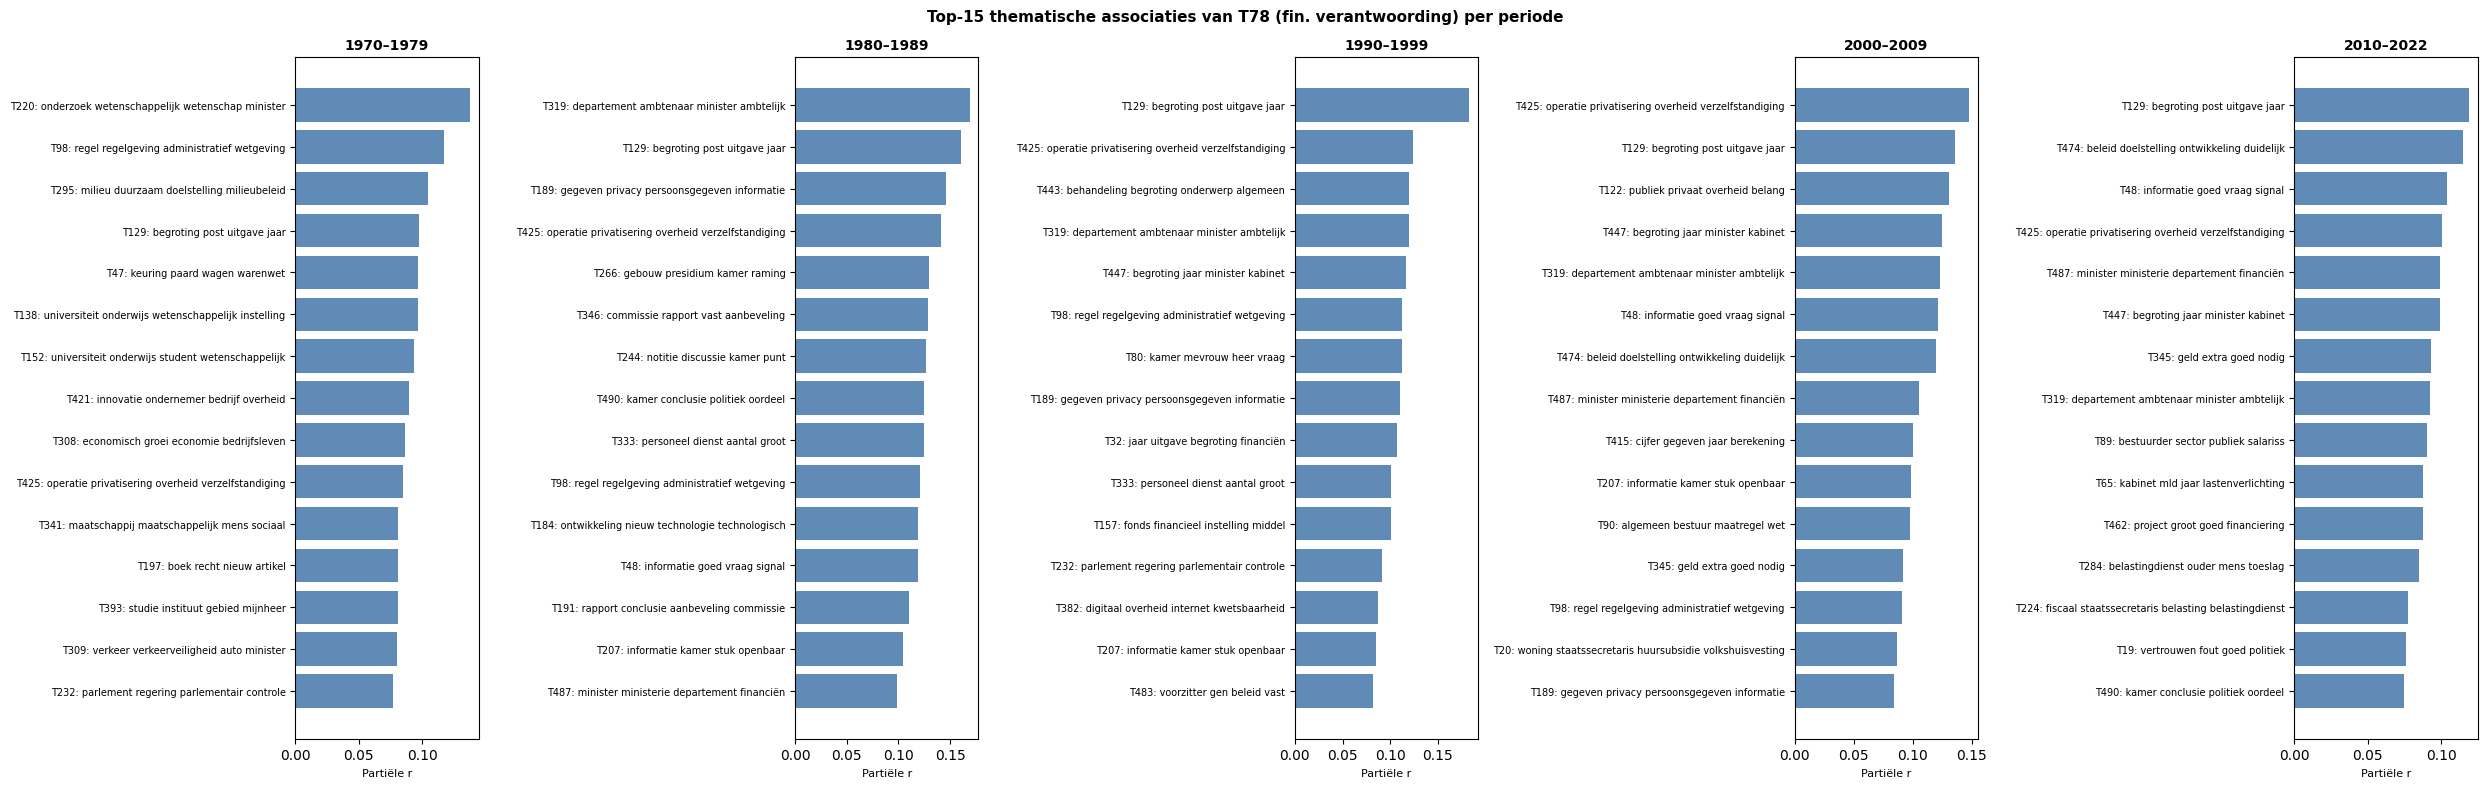

In [ ]:
# ── Figure: Top-15 associaties per periode ────────────────────────────────────
n = len(period_labels)
fig, axes = plt.subplots(1, n, figsize=(5*n, 8), sharey=False)

for ax, period in zip(axes, period_labels):
    df_p = period_dfs[period].head(15)
    labels = [f"T{int(r.topic_id)}: {' '.join(r.keywords.split()[:4])}"
              for _, r in df_p.iterrows()]
    ax.barh(labels[::-1], df_p["r_partial"].values[::-1], color="#4477AA", alpha=0.85)
    ax.axvline(0, color="black", lw=0.6)
    ax.set_title(period, fontsize=10, fontweight="bold")
    ax.set_xlabel("Partiële r", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Top-15 thematische associaties van T78 (fin. verantwoording) per periode",
             fontsize=11, fontweight="bold")
fig.tight_layout()
plt.savefig(FIGS/"eval_top_assoc_T78_by_period.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── Stabiele vs. veranderende associaties ─────────────────────────────────────
# Topics in top-30 van ALLE 5 periodes = stabiele kern
all_sets = [set(period_dfs[p]["topic_id"].astype(int)) for p in period_labels]
stable_ids = set.intersection(*all_sets)

# Annoteer met keywords (uit 2010-2022 csv, meest recent)
kw_map = dict(zip(period_dfs["2010–2022"]["topic_id"].astype(int),
                  period_dfs["2010–2022"]["keywords"]))
# fallback to 1970-1979
kw_map.update({int(r.topic_id): r.keywords
               for _, r in period_dfs["1970–1979"].iterrows() if int(r.topic_id) not in kw_map})

print(f"Stabiele kern ({len(stable_ids)} topics — aanwezig in alle 5 periodes):")
for tid in sorted(stable_ids):
    r_avg = np.mean([period_dfs[p].set_index("topic_id").loc[tid,"r_partial"]
                     for p in period_labels if tid in period_dfs[p]["topic_id"].values])
    print(f"  T{tid:3d} r̄={r_avg:.3f}  {kw_map.get(tid,'')[:60]}")


Stabiele kern (3 topics — aanwezig in alle 5 periodes):
  T129 r̄=0.139  begroting post uitgave jaar bedrag kamer
  T319 r̄=0.113  departement ambtenaar minister ambtelijk dienst ministerie
  T425 r̄=0.120  operatie privatisering overheid verzelfstandiging rijksdiens


In [10]:
# ── Opkomende en afnemende associaties (1970s → 2010s) ────────────────────────
c_first = period_dfs["1970–1979"].set_index("topic_id")
c_last  = period_dfs["2010–2022"].set_index("topic_id")
common  = c_first.index.astype(int).intersection(c_last.index.astype(int))
delta   = (c_last.loc[common,"r_partial"].values - c_first.loc[common,"r_partial"].values)
delta_s = pd.Series(delta, index=common).sort_values()

print("TOP 12 OPKOMEND (2010s vs 1970s):")
for tid, d in delta_s.tail(12).items():
    kws = kw_map.get(int(tid),'')[:55]
    print(f"  T{int(tid):3d} Δr={d:+.3f}  {kws}")

print("\nTOP 12 AFNEMEND:")
for tid, d in delta_s.head(12).items():
    kws = kw_map.get(int(tid),'')[:55]
    print(f"  T{int(tid):3d} Δr={d:+.3f}  {kws}")


TOP 12 OPKOMEND (2010s vs 1970s):
  T425 Δr=+0.016  operatie privatisering overheid verzelfstandiging rijks
  T129 Δr=+0.021  begroting post uitgave jaar bedrag kamer
  T319 Δr=+0.029  departement ambtenaar minister ambtelijk dienst ministe

TOP 12 AFNEMEND:
  T425 Δr=+0.016  operatie privatisering overheid verzelfstandiging rijks
  T129 Δr=+0.021  begroting post uitgave jaar bedrag kamer
  T319 Δr=+0.029  departement ambtenaar minister ambtelijk dienst ministe


---
### Deel 3: Interne cluster-structuur van het evaluatie-discourse

Hoe correleren de 6 evaluatietopics onderling, en verandert de clusterstructuur?


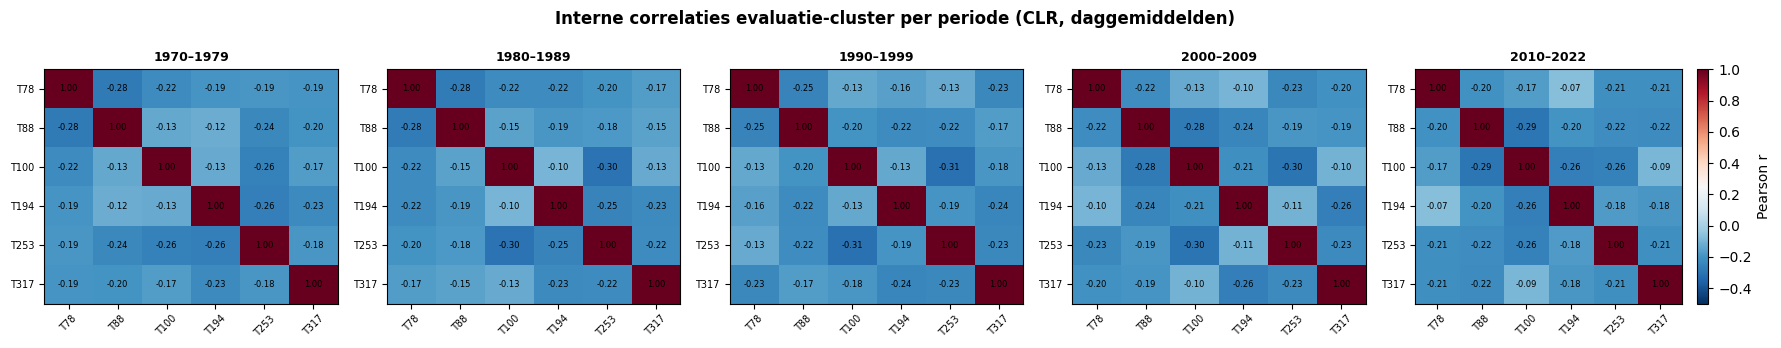

In [ ]:
# ── Interne correlaties: eval-cluster per periode ─────────────────────────────
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("/home/rb/Downloads/lda/lda/data-1945-2022-chunked")

def clr_transform(mat):
    mat = np.clip(mat, 1e-10, None)
    log_mat = np.log(mat)
    return log_mat - log_mat.mean(axis=1, keepdims=True)

df_full = pd.read_csv(DATA_DIR / "averaged_topics.csv",
                      usecols=["date"] + [str(t) for t in EVAL_TOPICS])
df_full["year"] = pd.to_datetime(df_full["date"]).dt.year

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
period_list = [("1970–1979",(1970,1979)),("1980–1989",(1980,1989)),
               ("1990–1999",(1990,1999)),("2000–2009",(2000,2009)),("2010–2022",(2010,2022))]

for ax, (label,(y0,y1)) in zip(axes, period_list):
    sub = df_full[(df_full.year>=y0) & (df_full.year<=y1)]
    daily = sub.groupby("date")[[str(t) for t in EVAL_TOPICS]].mean()
    clr = pd.DataFrame(clr_transform(daily.values), columns=EVAL_COLS)
    cmat = clr.corr().values
    im = ax.imshow(cmat, vmin=-0.5, vmax=1.0, cmap="RdBu_r", aspect="auto")
    ax.set_xticks(range(6)); ax.set_xticklabels([f"T{t}" for t in EVAL_TOPICS],
                                                  rotation=45, fontsize=7)
    ax.set_yticks(range(6)); ax.set_yticklabels([f"T{t}" for t in EVAL_TOPICS], fontsize=7)
    ax.set_title(label, fontsize=9, fontweight="bold")
    for i in range(6):
        for j in range(6):
            ax.text(j, i, f"{cmat[i,j]:.2f}", ha="center", va="center", fontsize=6)

fig.colorbar(im, ax=axes[-1], label="Pearson r", fraction=0.04)
fig.suptitle("Interne correlaties evaluatie-cluster per periode (CLR, daggemiddelden)",
             fontweight="bold")
fig.tight_layout()
plt.savefig(FIGS/"eval_internal_corr_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


---
### Deel 4: Institutionele dimensie — partij-deviatie

Welke partijen gebruiken het evaluatiediscours meer/minder dan het daggemiddelde?


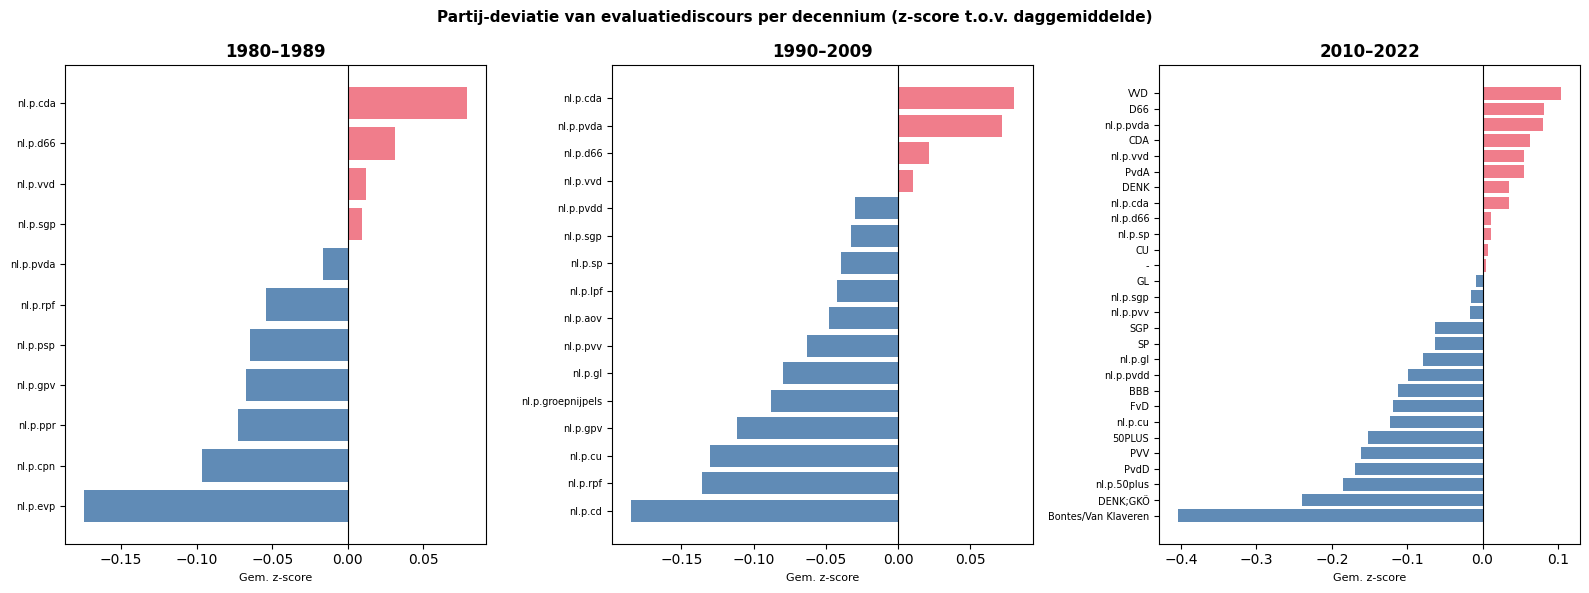

In [ ]:
# Load full data with party info
df_party = pd.read_csv(DATA_DIR / "averaged_topics.csv",
                       usecols=["party-ref","date"] + EVAL_COLS)
df_party["year"] = pd.to_datetime(df_party["date"]).dt.year
df_party["composite"] = df_party[EVAL_COLS].mean(axis=1)

# Z-score relative to day mean
daily_mean = df_party.groupby("date")["composite"].transform("mean")
daily_std  = df_party.groupby("date")["composite"].transform("std")
df_party["z"] = (df_party["composite"] - daily_mean) / (daily_std + 1e-9)

# Per decade
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
decade_ranges = [("1980–1989",(1980,1989)), ("1990–2009",(1990,2009)), ("2010–2022",(2010,2022))]

for ax, (label, (y0,y1)) in zip(axes, decade_ranges):
    sub = df_party[(df_party.year >= y0) & (df_party.year <= y1)]
    pz = sub.groupby("party-ref")["z"].agg(["mean","count"])
    pz = pz[pz["count"] >= 100].sort_values("mean")

    colors = ["#EE6677" if m > 0 else "#4477AA" for m in pz["mean"]]
    ax.barh(pz.index, pz["mean"], color=colors, alpha=0.85)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Gem. z-score", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Partij-deviatie van evaluatiediscours per decennium (z-score t.o.v. daggemiddelde)",
             fontweight="bold", fontsize=11)
fig.tight_layout()
plt.savefig(FIGS/"eval_party_deviation_decades.png", dpi=150, bbox_inches="tight")
plt.show()


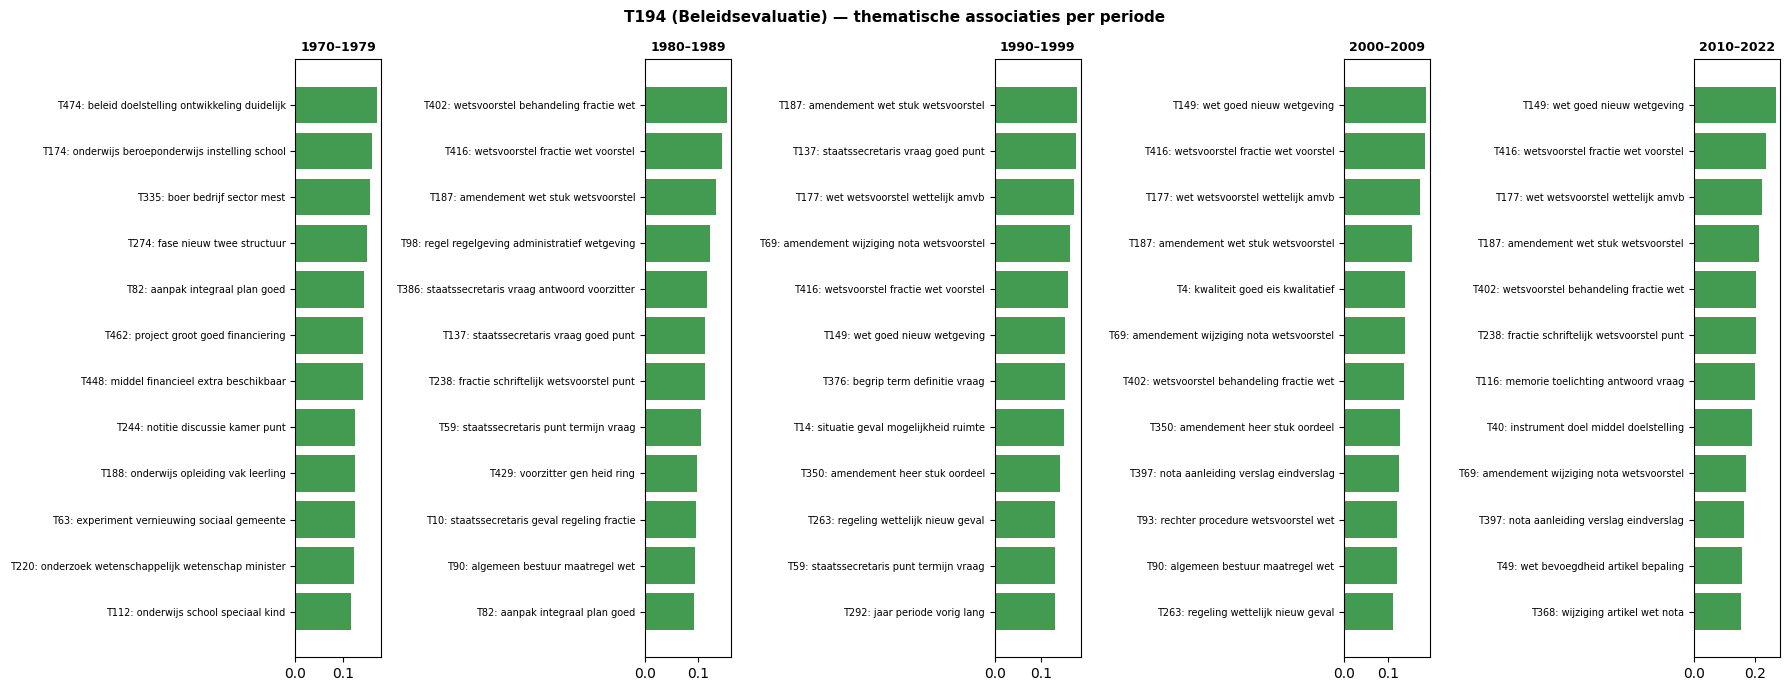

In [ ]:
# ── T194 (beleidsevaluatie) in context van wetgevingsproces ───────────────────
# Reload and show T194 associations across periods

all_t194 = pd.read_csv(RESULTS / "eval_T194_all_periods_top30.csv")

fig, axes = plt.subplots(1, 5, figsize=(18, 7))
for ax, (period, grp) in zip(axes, all_t194.groupby("period")):
    top = grp.sort_values("r_partial", ascending=False).head(12)
    labels = [f"T{int(r.topic_id)}: {' '.join(r.keywords.split()[:4])}"
              for _, r in top.iterrows()]
    ax.barh(labels[::-1], top["r_partial"].values[::-1], color="#228833", alpha=0.85)
    ax.axvline(0, color="black", lw=0.6)
    ax.set_title(period, fontsize=9, fontweight="bold")
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("T194 (Beleidsevaluatie) — thematische associaties per periode",
             fontweight="bold", fontsize=11)
fig.tight_layout()
plt.savefig(FIGS/"eval_T194_by_period.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# ── Samenvatting: welke topics correleren consistent met evaluatiediscours ─────
summary_rows = []
for focal_id in EVAL_TOPICS:
    all_df = pd.read_csv(RESULTS / f"eval_T{focal_id}_all_periods_top30.csv")
    # Topics in top-30 of 4+ periods
    cnt = all_df.groupby("topic_id").size()
    consistent = cnt[cnt >= 4].index.tolist()
    avg_r = all_df[all_df.topic_id.isin(consistent)].groupby("topic_id")["r_partial"].mean()
    kws_map = dict(zip(all_df["topic_id"], all_df["keywords"]))
    for tid, r in avg_r.nlargest(5).items():
        summary_rows.append({
            "eval_topic": f"T{focal_id}: {list(EVAL_TOPICS.values())[list(EVAL_TOPICS.keys()).index(focal_id)]}",
            "assoc_topic": int(tid),
            "r_avg": r,
            "keywords": ' '.join(str(kws_map.get(tid,'')).split()[:6])
        })

summary = pd.DataFrame(summary_rows)
print("Consistente thematische associaties (top-5 per eval-topic, ≥4 periodes):")
print(summary.to_string(index=False))


Consistente thematische associaties (top-5 per eval-topic, ≥4 periodes):
                    eval_topic  assoc_topic    r_avg                                                                       keywords
T78: T78 · Fin. verantwoording          129 0.139121                                       begroting post uitgave jaar bedrag kamer
T78: T78 · Fin. verantwoording          425 0.119516      operatie privatisering overheid verzelfstandiging rijksdienst departement
T78: T78 · Fin. verantwoording          319 0.113248                     departement ambtenaar minister ambtelijk dienst ministerie
T78: T78 · Fin. verantwoording           98 0.110496                    regel regelgeving administratief wetgeving deregulering wet
T78: T78 · Fin. verantwoording          447 0.106498                          begroting jaar minister kabinet financiën structureel
        T88: T88 · Integriteit          207 0.111258                      informatie kamer stuk openbaar openbaarheid vertrouwelijk
   